# Exercises week 36

## Deriving and Implementing Ridge Regression

## Learning goals

After completing these exercises, you will know how to
- Take more derivatives of simple products between vectors and matrices
- Implement Ridge regression using the analytical expressions
- Scale data appropriately for linear regression
- Evaluate a model across two different hyperparameters

## Exercise 1 - Choice of model and degrees of freedom

**a)** How many degrees of freedom does an OLS model fit to the features $x, x^2, x^3$ and the intercept have? 

**b)** Why is it bad for a model to have too many degrees of freedom?

**c)** Why is it bad for a model to have too few degrees of freedom?

**d)** Read [chapter 3.4.1 of Hastie et al.'s book](https://link.springer.com/book/10.1007/978-0-387-84858-7). What is the expression for the effective degrees of freedom of the ridge regression fit?

**e)** Why might we want to use Ridge regression instead of OLS?

**f)** Why migth we want to use OLS instead of Ridge regression?

### Answers:
a) We have 4 degrees of freedom one for each x and the last for the intercept

b) It uses more computational power to fit. And if the data follows a more simple distribution the fit will be worse.

c) The fit to the data might be poor due to underfitting. More degrees of freedom leads to more flexible models. And are able to fit more complex distributions

d) 
$\hat{\beta}^{ridge}=\argmin\limits_{\beta}\left\{\sum_{i=1}^{N}\left( y_i - \beta_0 + \lambda\sum_{j=1}^{p}\beta_j^2 \right)\right\}$

$df(\lambda)=\sum_{j=1}^{p}\frac{d_j^2}{d_j^2+\lambda}$

Where $df(\lambda)$ is the effective degrees of freedom. It monotone decreasing function of $\lambda$. As the degrees of freedom decreases when lambda increases. Our fit become less paramterized

e) 
We would want to use ridge regression when we have overparamaterized our problem. When we want to use a more simple fit towards our problem. Sometimes this could even lead to a better fit to our test data, that our original model

f)
When we want to use a simpler model. More complex models are not always better. Somtimes removing paramterers with a penalized term does not lead to a better fit

## Exercise 2 - Deriving the expression for Ridge Regression

The aim here is to derive the expression for the optimal parameters using Ridge regression.

The expression for the standard Mean Squared Error (MSE) which we used to define our cost function and the equations for the ordinary least squares (OLS) method, was given by the optimization problem

$$
{\displaystyle \min_{\boldsymbol{\beta}\in {\mathbb{R}}^{p}}}\frac{1}{n}\left\{\left(\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\beta}\right)^T\left(\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\beta}\right)\right\}.
$$

By minimizing the above equation with respect to the parameters $\boldsymbol{\beta}$ we could then obtain an analytical expression for the parameters $\boldsymbol{\hat\beta_{OLS}}$.

We can add a regularization parameter $\lambda$ by
defining a new cost function to be optimized, that is

$$
{\displaystyle \min_{\boldsymbol{\beta}\in
{\mathbb{R}}^{p}}}\frac{1}{n}\vert\vert \boldsymbol{y}-\boldsymbol{X}\boldsymbol{\beta}\vert\vert_2^2+\lambda\vert\vert \boldsymbol{\beta}\vert\vert_2^2
$$

which leads to the Ridge regression minimization problem. (One can require as part of the optimization problem that $\vert\vert \boldsymbol{\beta}\vert\vert_2^2\le t$, where $t$ is a finite number larger than zero. We will not implement that in this course.)

### a) Expression for Ridge regression

Show that the optimal parameters

$$
\hat{\boldsymbol{\beta}}_{\mathrm{Ridge}} = \left(\boldsymbol{X}^T\boldsymbol{X}+\lambda\boldsymbol{I}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y},
$$

with $\boldsymbol{I}$ being a $p\times p$ identity matrix.

The ordinary least squares result is

$$
\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} = \left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y},
$$

#### Answer:

We have our minimizing function defined $\min\limits_{\beta\in\mathbb{R}^p}\frac{1}{n}||y-\bf{X}\bf{\beta}||_2^2+\lambda||\bf{\beta}||_2^2$

$$\frac{1}{n}((y-\bf{X}\beta)^T(y-\bf{X}\beta))+\lambda\beta^T\beta $$


$$
\frac{1}{n}(y^Ty -y^T\bf{X}\beta -\beta^TX^T y +\beta^T\bf{X}^T\bf{X}\beta) +\lambda\beta^T\beta
$$

We have that $y^t\bf{X}\beta = \beta^T\bf{X}^Ty$ since they are both scalars

$$
\mathcal{L}(\beta) = \frac{1}{n}(y^Ty -2\beta^TX^T y +\beta^T\bf{X}^T\bf{X}\beta) +\lambda\beta^T\beta
$$

$$
\frac{\partial\mathcal{L}(\beta)}{\partial\beta}=\frac{1}{n} \frac{\partial y^Ty}{\partial\beta}-\frac{2}{n}\frac{\partial\beta^TX^Ty}{\partial \beta}+\frac{1}{n}\frac{\partial \beta^TX^TX\beta}{\partial \beta}+\frac{\partial\lambda\beta^T\beta}{\partial\beta}
$$ 

$$
\frac{\partial\mathcal{L}(\beta)}{\partial\beta}= \frac{2}{n}X^TX\beta - \frac{2}{n}X^Ty+2\lambda\beta 
$$

We set the derivative
$$
\frac{\partial\mathcal{L}(\beta)}{\partial\beta} = 0
$$
$$
\frac{2}{n}X^Ty = \frac{2}{n}X^TX\beta +2\lambda\beta
$$
$$
\frac{1}{n}X^Ty = \frac{1}{n}X^TX\beta +\lambda\beta
$$
We multipy by n
$$
X^Ty = X^TX\beta +n\lambda\beta
$$

$$
X^Ty=(X^TX+n\lambda I)\beta
$$

$$
\beta = (X^TX+n\lambda I)^{-1}X^Ty
$$

## Exercise 3 - Scaling data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
n = 100
x = np.linspace(-3, 3, n)
y = np.exp(-x**2) + 1.5 * np.exp(-(x-2)**2) + np.random.normal(n)

**a)** Adapt your function from last week to only include the intercept column if the boolean argument `intercept` is set to true.

In [3]:
def polynomial_features(x, p, intercept=False):
    n = len(x)
    if intercept:
        p = p+1
    X = np.zeros((n, p))
    for i in range(p):
            X[:,i] = x**(i+1)
    return X

**b)** Split your data into training and test data(80/20 split)

In [4]:
X = polynomial_features(x, 3)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
x_train = X_train[:, 0] # These are used for plotting
x_test = X_test[:, 0] # These are used for plotting

**c)** Scale your design matrix with the sklearn standard scaler, though based on the mean and standard deviation of the training data only.

In [6]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
y_offset = np.mean(y_train)

## Exercise 4 - Implementing Ridge Regression

**a)** Implement a function for computing the optimal Ridge parameters using the expression from **2a)**.

In [7]:
def Ridge_parameters(X, y,lambda_=1):
    # Assumes X is scaled and has no intercept column
    
    return np.linalg.inv(X.T @ X+np.identity(X.shape[1])*lambda_) @ X.T @ y

beta = Ridge_parameters(X_train_s, y_train)

**b)** Fit a model to the data, and plot the prediction using both the training and test x-values extracted before scaling, and the y_offset.

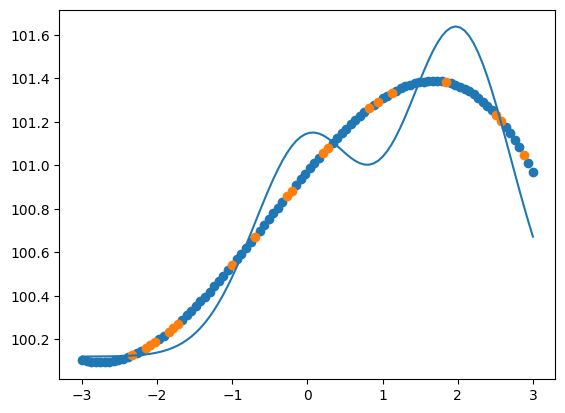

In [8]:
plt.plot(x, y)
plt.scatter(x_train, X_train_s @ beta + y_offset)
plt.scatter(x_test, X_test_s @ beta + y_offset)
plt.show()

## Exercise 4 - Testing multiple hyperparameters

**a)** Compute the MSE of your ridge model for polynomials of degrees 1 to 5 with lambda set to 0.01. Plot the MSE as a function of polynomial degree.

**b)** Compute the MSE of your ridge model for a polynomial with degree 3, and with lambdas from $10^{-1}$ to $10^{-5}$ on a logarithmic scale. Plot the MSE as a function of lambda.

**c)** Compute the MSE of your ridge model for polynomials of degrees 1 to 5, and with lambdas from $10^{-1}$ to $10^{-5}$ on a logarithmic scale. Plot the MSE as a function of polynomial degree and lambda using a [heatmap](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html).

### Answers:

### a) 

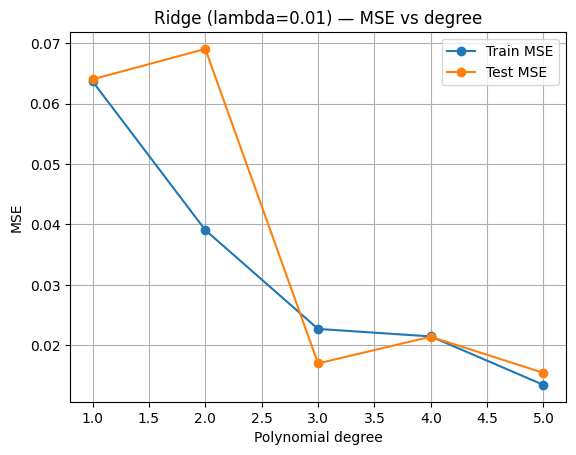

In [9]:

degrees = range(1, 6)
lambda_ = 0.01
mse_train, mse_test = [], []

for pol in degrees:
    X = polynomial_features(x, pol)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    y_offset = np.mean(y_train)
    y_train_c = y_train - y_offset

    beta = Ridge_parameters(X_train_s, y_train_c, lambda_=lambda_)
    y_pred_train = X_train_s @ beta + y_offset
    y_pred_test = X_test_s @ beta + y_offset

    mse_train.append(np.mean((y_train - y_pred_train)**2))
    mse_test.append(np.mean((y_test - y_pred_test)**2))



plt.figure()
plt.plot(list(degrees), mse_train, marker='o', label='Train MSE')
plt.plot(list(degrees), mse_test, marker='o', label='Test MSE')
plt.xlabel('Polynomial degree')
plt.ylabel('MSE')
plt.title(f'Ridge (lambda={lambda_}) — MSE vs degree')
plt.legend()
plt.grid(True)
plt.show()

b)

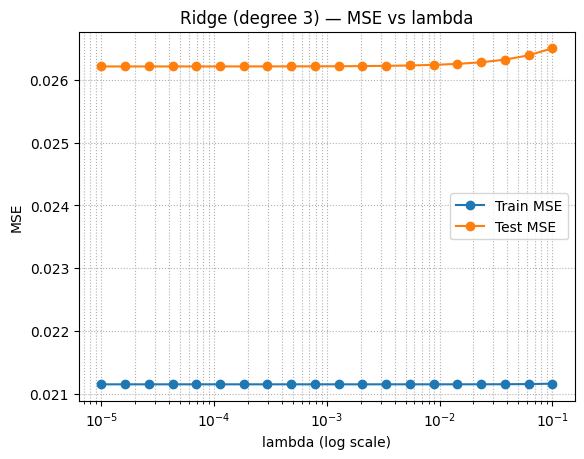

In [10]:
p = 3
lambdas = np.logspace(-5, -1, 20)

X = polynomial_features(x, p)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

y_offset = np.mean(y_train)
y_train_c = y_train - y_offset

mse_train, mse_test = [], []

for lambda_ in lambdas:
    beta = Ridge_parameters(X_train_s, y_train_c, lambda_=lambda_)
    y_pred_train = X_train_s @ beta + y_offset
    y_pred_test  = X_test_s  @ beta + y_offset
    mse_train.append(np.mean((y_train - y_pred_train)**2))
    mse_test.append(np.mean((y_test  - y_pred_test )**2))

plt.figure()
plt.semilogx(lambdas, mse_train, marker='o', label='Train MSE')
plt.semilogx(lambdas, mse_test,  marker='o', label='Test MSE')
plt.xlabel('lambda (log scale)')
plt.ylabel('MSE')
plt.title(f'Ridge (degree {p}) — MSE vs lambda')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()


This result seems a bit strange as you wold expect the model to be penalized harder for paramaters and therefore having a worse fit in both the train and the test. But it makes sense that the effect is higher on the test MSE

c)

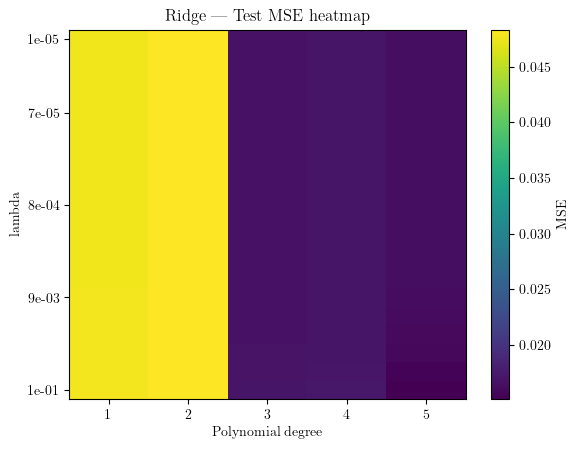

In [ ]:
degrees = range(1, 6)
lambdas = np.logspace(-1, -5, 20)

idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42)

mse_grid = np.zeros((len(lambdas), len(degrees)))

for j, p in enumerate(degrees):
    X = polynomial_features(x, p)
    X_train, X_test = X[idx_tr], X[idx_te]
    y_train, y_test = y[idx_tr], y[idx_te]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    y_offset = np.mean(y_train)
    y_train_c = y_train - y_offset

    for i, lambda_ in enumerate(lambdas):
        beta = Ridge_parameters(X_train_s, y_train_c, lambda_)
        y_pred_test = X_test_s @ beta + y_offset
        mse_grid[i, j] = np.mean((y_test - y_pred_test)**2)



plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

plt.figure()
im = plt.imshow(mse_grid, origin='lower', aspect='auto')
plt.colorbar(im, label='MSE')
plt.xticks(range(len(degrees)), list(degrees))
yticks_idx = [0, 5, 10, 15, 19]
plt.yticks(yticks_idx, [f"{lambdas[k]:.0e}" for k in yticks_idx])
plt.xlabel('Polynomial degree')
plt.ylabel('lambda')
plt.title('Ridge — Test MSE heatmap')
plt.savefig("/Users/bror/Downloads/figures_fys/Heatmap.pdf")
plt.show()


It seems like models with a with a higher complexity and higher lambda does better on the test set. However i used some chatgpt on the plotting so i dont know if something is wrong. It seems like every column is a bit homogeneous